In [ ]:
import os
import pandas as pd
from PIL import Image
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.tensorboard import SummaryWriter
from datetime import datetime
import glob
import random
from datetime import datetime



In [11]:
# 사용자 정의 Dataset 클래스
class PostureDataset(torch.utils.data.Dataset):
    def __init__(self, dataframe, image_dir, transform=None):
        self.data = dataframe
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        image_path = os.path.join(self.image_dir, row["filename"])
        image = Image.open(image_path).convert("RGB")
        label = row["class_id"]
        if self.transform:
            image = self.transform(image)
        return image, label


def set_seed(seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# 호출
set_seed(42)


In [ ]:
# 백본 모델 로드 및 분류기 제거 함수
def get_backbone(name):
    if name == 'efficientnet_b0':
        model = models.efficientnet_b0(pretrained=True)
        in_features = model.classifier[1].in_features
        model.classifier = nn.Identity()
    elif name == 'resnet50':
        model = models.resnet50(pretrained=True)
        in_features = model.fc.in_features
        model.fc = nn.Identity()
    elif name == 'mobilenet_v3_large':
        model = models.mobilenet_v3_large(pretrained=True)
        in_features = model.classifier[0].in_features
        model.classifier = nn.Identity()
    elif name == 'convnext_tiny':
        model = models.convnext_tiny(pretrained=True)
        in_features = model.classifier[2].in_features
        model.classifier = nn.Identity()
    else:
        raise ValueError(f"Unknown model name: {name}")
    
    return model, in_features
# MLP Head 정의 함수
def get_mlp_head(in_features):
    return nn.Sequential(
        nn.BatchNorm1d(in_features),
        nn.Linear(in_features, 256),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(256, 64),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(64, 1)
    )

# # EarlyStopping 클래스
# class EarlyStopping:
#     def __init__(self, patience=30, delta=0.0, checkpoint_path='checkpoint.pt'):
#         self.patience = patience
#         self.delta = delta
#         self.counter = 0
#         self.best_score = None
#         self.early_stop = False
#         self.checkpoint_path = checkpoint_path

#     def __call__(self, val_loss, model):
#         score = -val_loss

#         if self.best_score is None:
#             self.best_score = score
#             self.save_checkpoint(model)
#         elif score < self.best_score + self.delta:
#             self.counter += 1
#             print(f"🟡 EarlyStopping counter: {self.counter} / {self.patience}")
#             if self.counter >= self.patience:
#                 print("🛑 EarlyStopping triggered! Stopping training.")
#                 self.early_stop = True
#         else:
#             self.best_score = score
#             self.save_checkpoint(model)
#             self.counter = 0

#     def save_checkpoint(self, model):
#         """Validation loss가 개선될 때만 모델 저장"""
#         torch.save(model.state_dict(), self.checkpoint_path)
#         print(f"✅ Model saved to {self.checkpoint_path}")
class EarlyStoppingF1:
    def __init__(self, patience=10, delta=0.0, checkpoint_path='mobilenet_best_model.pt'):
        self.patience = patience
        self.delta = delta
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.checkpoint_path = checkpoint_path

    def __call__(self, val_f1, model):
        if self.best_score is None or val_f1 > self.best_score + self.delta:
            self.best_score = val_f1
            self.save_checkpoint(model)
            self.counter = 0
        else:
            self.counter += 1
            print(f"🟡 EarlyStopping counter: {self.counter} / {self.patience}")
            if self.counter >= self.patience:
                print("🛑 EarlyStopping triggered!")
                self.early_stop = True

    def save_checkpoint(self, model):
        torch.save(model.state_dict(), self.checkpoint_path)
        print(f"✅ Best model saved to {self.checkpoint_path}")

# 백본 모델 로드 및 분류기 제거 함수
def get_backbone(name):
    if name == 'efficientnet_b0':
        model = models.efficientnet_b0(pretrained=True)
        in_features = model.classifier[1].in_features
        model.classifier = nn.Identity()
    elif name == 'resnet50':
        model = models.resnet50(pretrained=True)
        in_features = model.fc.in_features
        model.fc = nn.Identity()
    elif name == 'mobilenet_v3_large':
        model = models.mobilenet_v3_large(pretrained=True)
        in_features = model.classifier[0].in_features
        model.classifier = nn.Identity()
    elif name == 'convnext_tiny':
        model = models.convnext_tiny(pretrained=True)
        in_features = model.classifier[2].in_features
        model.classifier = nn.Identity()
    else:
        raise ValueError(f"Unknown model name: {name}")
    
    return model, in_features

# MLP Head 정의 함수
def get_mlp_head(in_features):
    return nn.Sequential(
        nn.BatchNorm1d(in_features),
        nn.Linear(in_features, 256),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(256, 64),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(64, 1)
    )

# 에폭별 특성 데이터 저장 함수 (날짜 폴더 포함)
def save_epoch_data(epoch, features, labels, setname, backbone, save_dir='embeddings'):
    today = datetime.now().strftime('%Y%m%d')
    save_path = os.path.join(save_dir, today, backbone)
    os.makedirs(save_path, exist_ok=True)
    np.save(f"{save_path}/epoch_{epoch:03d}_{setname}_features.npy", features)
    np.save(f"{save_path}/epoch_{epoch:03d}_{setname}_labels.npy", labels)

# 최신 날짜 폴더를 찾는 헬퍼 함수
def get_latest_date_folder(base_dir):
    date_folders = sorted([f for f in os.listdir(base_dir) if os.path.isdir(os.path.join(base_dir, f)) and f.isdigit() and len(f) == 8], reverse=True)
    if not date_folders:
        raise FileNotFoundError(f"No date-stamped folders found in {base_dir}")
    return date_folders[0]

# 학습 에폭 함수
def train_epoch(loader, model, criterion, optimizer, device, is_train=True):
    model.train() if is_train else model.eval()
    running_loss = 0.0
    preds, labels = [], []

    for images, targets in loader:
        images = images.to(device)
        targets = targets.float().to(device).unsqueeze(1)

        if is_train:
            optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, targets)

        if is_train:
            loss.backward()
            optimizer.step()

        running_loss += loss.item() * images.size(0)

        preds_batch = (torch.sigmoid(outputs).detach().cpu().numpy() > 0.5).astype(int)
        targets_batch = targets.detach().cpu().numpy().astype(int)

        preds.extend(preds_batch)
        labels.extend(targets_batch)

    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds)

    return running_loss / len(loader.dataset), acc, f1




In [4]:
if torch.backends.mps.is_available() and torch.backends.mps.is_built():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

Using device: cuda


In [ ]:
# CSV 파일 불러오기
train_df = pd.read_csv("../dataset-modification/train_pose_parsed.csv")[["filename", "class_id"]]
valid_df = pd.read_csv("../dataset-modification/valid_pose_parsed.csv")[["filename", "class_id"]]

# filename 중복 처리 (class_id의 min 값 선택)
train_df = train_df.groupby("filename")["class_id"].min().reset_index()
valid_df = valid_df.groupby("filename")["class_id"].min().reset_index()

# 클래스 가중치 계산
class_weights = compute_class_weight('balanced', classes=np.unique(train_df["class_id"]), y=train_df["class_id"])
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32)

# 이미지 경로 정의
train_image_dir = "../dataset-modification/train-visualized/images/"
valid_image_dir = "../dataset-modification/valid-visualized/images/"

# 데이터 증강 및 정규화 Transform 정의
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),  # 30도는 과도, 15도 권장
    transforms.ColorJitter(
        brightness=0.2, contrast=0.2, saturation=0.1, hue=0.05
    ),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.1, 0.1),
        scale=(0.95, 1.05)  # shear 제거
    ),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])


# Dataset 생성
train_dataset = PostureDataset(train_df, train_image_dir, transform=train_transform)
val_dataset = PostureDataset(valid_df, valid_image_dir, transform=val_transform)


print("Train 클래스 분포:\n", train_df["class_id"].value_counts())
print("Valid 클래스 분포:\n", valid_df["class_id"].value_counts())
print("Class weights:", class_weights_tensor)

Train 클래스 분포:
 0    1586
1     995
Name: class_id, dtype: int64
Valid 클래스 분포:
 0    408
1    292
Name: class_id, dtype: int64
Class weights: tensor([0.8137, 1.2970])


In [6]:
original_train_df = pd.read_csv("../dataset-modification/train_pose_parsed.csv")
print("원본 row 수:", len(original_train_df))
print("고유 filename 수:", original_train_df["filename"].nunique())

원본 row 수: 2911
고유 filename 수: 2581


In [ ]:
# 장치 설정
device = torch.device("mps" if torch.backends.mps.is_available() and torch.backends.mps.is_built()
                      else "cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 설정
backbone_name = "mobilenet_v3_large"
num_epochs = 40
log_interval = 1
# checkpoint_path = f"{backbone_name}_best_mode l.pt"
results = {
    "train_loss": [], "val_loss": [],
    "train_acc": [], "val_acc": [],
    "train_f1": [], "val_f1": []
}

# 모델 구성
backbone, in_features = get_backbone(backbone_name)
mlp_head = get_mlp_head(in_features)
model = nn.Sequential(backbone, mlp_head).to(device)
# 날짜와 시각을 포함한 파일명 자동 생성
now = datetime.now().strftime("%Y%m%d_%H%M%S")
checkpoint_path = f"mobilenet_best_model_{now}.pt"
# 손실 함수 및 옵티마이저
criterion = nn.BCEWithLogitsLoss(pos_weight=class_weights_tensor[1].to(device))
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# EarlyStopping
# early_stopper = EarlyStopping(patience=15, delta=0.001, checkpoint_path=checkpoint_path)
early_stopping = EarlyStoppingF1(patience=15,checkpoint_path=checkpoint_path)


# TensorBoard Writer
writer = SummaryWriter(log_dir=f"runs/{backbone_name}_{datetime.now().strftime('%Y%m%d_%H%M%S')}")
import os
import torch
from torch.utils.data import DataLoader

def main():
    # DataLoader 생성
    # ✅ Jupyter용 설정
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=os.cpu_count() // 2 or 1) # num_workers 추가
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=os.cpu_count() // 2 or 1) # num_workers 추가
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0)


    # 학습 루프
    for epoch in range(num_epochs):
        print(f"\n📘 Epoch {epoch+1}/{num_epochs}")

        train_loss, train_acc, train_f1 = train_epoch(train_loader, model, criterion, optimizer, device, is_train=True)
        val_loss, val_acc, val_f1 = train_epoch(val_loader, model, criterion, optimizer, device, is_train=False)

        print(f"Train Loss={train_loss:.4f}, Acc={train_acc:.4f}, F1={train_f1:.4f} | "
            f"Val Loss={val_loss:.4f}, Acc={val_acc:.4f}, F1={val_f1:.4f}")
        
        # 결과 저장
        results["train_loss"].append(train_loss)
        results["val_loss"].append(val_loss)
        results["train_acc"].append(train_acc)
        results["val_acc"].append(val_acc)
        results["train_f1"].append(train_f1)
        results["val_f1"].append(val_f1)

        # TensorBoard 기록
        writer.add_scalar('Loss/train', train_loss, epoch)
        writer.add_scalar('Loss/val', val_loss, epoch)
        writer.add_scalar('Accuracy/train', train_acc, epoch)
        writer.add_scalar('Accuracy/val', val_acc, epoch)
        writer.add_scalar('F1/train', train_f1, epoch)
        writer.add_scalar('F1/val', val_f1, epoch)

        # Early Stopping 체크
        # early_stopper(val_loss, model)
        # if early_stopper.early_stop:
        #     break
        # 매 epoch 후
        early_stopping(val_f1, model)
        if early_stopping.early_stop:
            break
        # 특성 저장
        if epoch % log_interval == 0:
            model.eval()
            for split_name, loader in zip(["train", "val"], [train_loader, val_loader]):
                feats_list, labels_list = [], []
                with torch.no_grad():
                    for imgs, lbls in loader:
                        imgs, lbls = imgs.to(device), lbls.to(device)
                        feats = backbone(imgs)
                        feats_list.append(feats.cpu())
                        labels_list.append(lbls.cpu())
                all_feats = torch.cat(feats_list, dim=0).numpy()
                all_lbls = torch.cat(labels_list, dim=0).numpy()
                save_epoch_data(epoch, all_feats, all_lbls, split_name, backbone_name)

    writer.close()
    print(f"\n✅ Training complete. Best model saved to: {checkpoint_path}")


if __name__ == "__main__":
    main()



Using device: cuda


c:\Users\main\miniconda3\envs\PoseDetect-env\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\main\miniconda3\envs\PoseDetect-env\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V3_Large_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V3_Large_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)



📘 Epoch 1/40
Train Loss=0.7368, Acc=0.6377, F1=0.4218 | Val Loss=0.7247, Acc=0.6271, F1=0.6449
✅ Model saved to mobilenet_v3_large_best_model.pt

📘 Epoch 2/40
Train Loss=0.6179, Acc=0.7195, F1=0.6405 | Val Loss=0.5238, Acc=0.7700, F1=0.7440
✅ Model saved to mobilenet_v3_large_best_model.pt

📘 Epoch 3/40
Train Loss=0.5064, Acc=0.7838, F1=0.7273 | Val Loss=0.4606, Acc=0.8157, F1=0.7733
✅ Model saved to mobilenet_v3_large_best_model.pt

📘 Epoch 4/40
Train Loss=0.4224, Acc=0.8318, F1=0.7851 | Val Loss=0.4335, Acc=0.8386, F1=0.7993
✅ Model saved to mobilenet_v3_large_best_model.pt

📘 Epoch 5/40
Train Loss=0.3885, Acc=0.8431, F1=0.7986 | Val Loss=0.4783, Acc=0.8286, F1=0.7744
🟡 EarlyStopping counter: 1 / 15

📘 Epoch 6/40
Train Loss=0.3597, Acc=0.8621, F1=0.8220 | Val Loss=0.4647, Acc=0.8200, F1=0.7941
🟡 EarlyStopping counter: 2 / 15

📘 Epoch 7/40
Train Loss=0.3280, Acc=0.8729, F1=0.8373 | Val Loss=0.4256, Acc=0.8486, F1=0.8166
✅ Model saved to mobilenet_v3_large_best_model.pt

📘 Epoch 8/40


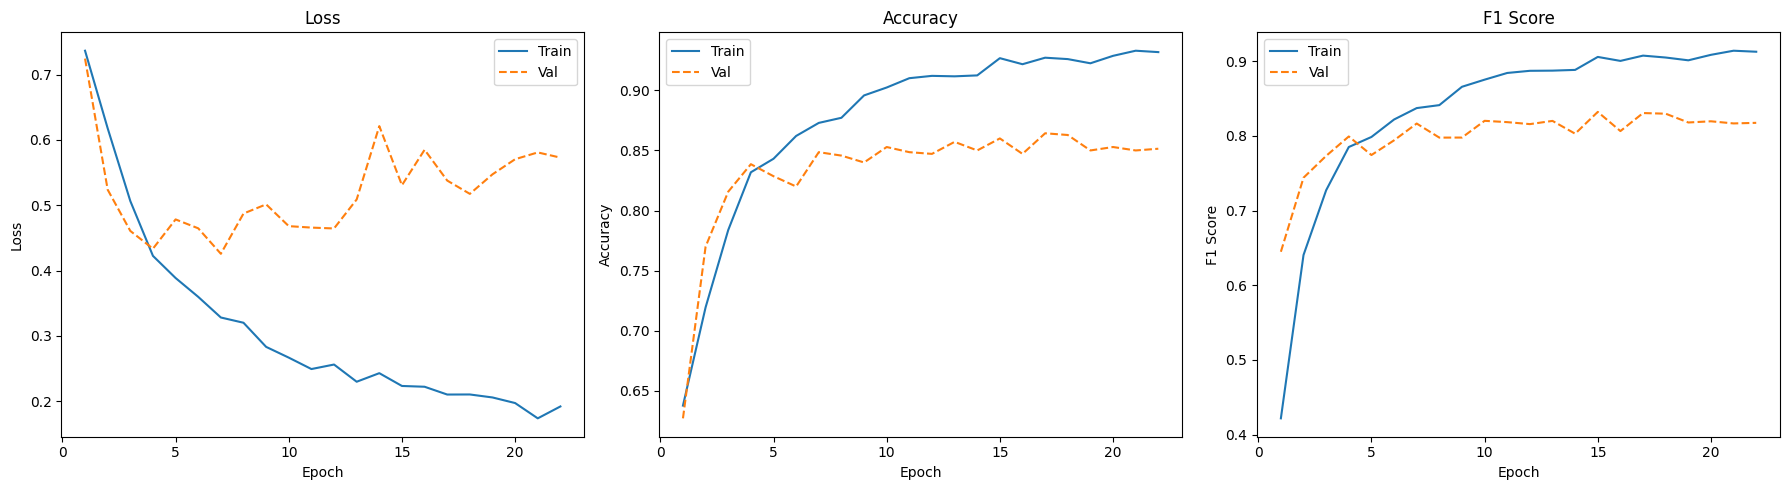

In [8]:
import matplotlib.pyplot as plt

epochs = range(1, len(results["train_loss"]) + 1)
plt.figure(figsize=(18, 5))

# 1. Loss
plt.subplot(1, 3, 1)
plt.plot(epochs, results["train_loss"], label="Train")
plt.plot(epochs, results["val_loss"], '--', label="Val")
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# 2. Accuracy
plt.subplot(1, 3, 2)
plt.plot(epochs, results["train_acc"], label="Train")
plt.plot(epochs, results["val_acc"], '--', label="Val")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# 3. F1 Score
plt.subplot(1, 3, 3)
plt.plot(epochs, results["train_f1"], label="Train")
plt.plot(epochs, results["val_f1"], '--', label="Val")
plt.title("F1 Score")
plt.xlabel("Epoch")
plt.ylabel("F1 Score")
plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# (1) 예측값과 정답값을 수집
# preds, labels는 검증/테스트 데이터 전체에 대해 아래와 같이 추출
# 예시:
# preds: [0, 1, 1, 0, ...]
# labels: [0, 1, 0, 0, ...]

# (2) 혼동행렬 및 리포트 출력
cm = confusion_matrix(labels, preds)
print("Confusion Matrix:")
print(cm)

print("\nDetailed Classification Report:")
print(classification_report(labels, preds, target_names=["Class 0", "Class 1"]))
